In [29]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt

from sk_decoder import RetinaDecoder
from sk_train_decoder import RGCDataset
from sk_utils import Utils as u

# Limited training set size (test)

In [80]:
results = torch.load("/home/rotation/Desktop/LNP_LN_LN_Models/test_weights_final.pt")
results.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

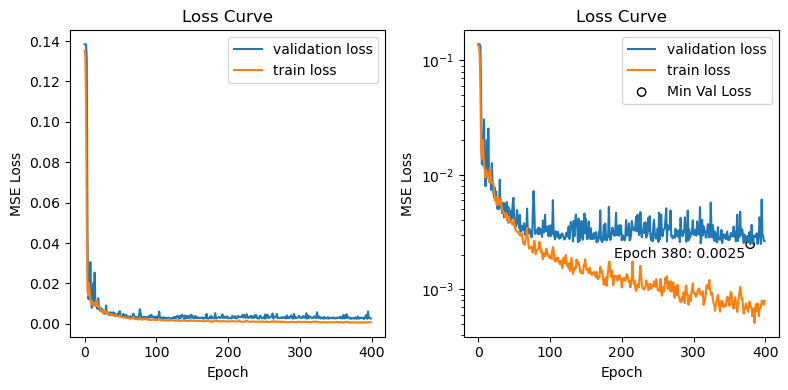

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(results["val_loss_history"], label="validation loss")
ax[0].plot(results["train_loss_history"], label="train loss")
ax[0].legend()

ax[0].set_title("Loss Curve")
ax[0].set_ylabel("MSE Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(results["val_loss_history"], label="validation loss")
ax[1].plot(results["train_loss_history"], label="train loss")

# show the minimum validation loss model
ax[1].scatter(379, min(results["val_loss_history"]), edgecolor="black", marker="o", facecolor="none", label="Min Val Loss")
ax[1].text(379-190, min(results["val_loss_history"])-0.0006, f"Epoch 380: {min(results['val_loss_history']):.4f}")
ax[1].legend()

ax[1].set_yscale("log")
ax[1].set_title("Loss Curve")
ax[1].set_ylabel("MSE Loss")
ax[1].set_xlabel("Epoch")

fig.set_tight_layout(True)
plt.show()

In [86]:
# Let's see if we can rebuild some of the input images (and if we can try to rebuild some out of distribution images)
# 1. Load Configurations
train_cfg = u.read_params("params_training.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Data Preparation
dataset = RGCDataset("test_activations.pt", "params_training.yaml")

# Validation split
val_split = train_cfg.get("validation_split", 0.1)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=False, num_workers=0)

# 3. Model Initialization
n_mosaics, max_n_cells, _ = dataset.firing_rates.shape
decoder_params = {
    "n_cells": n_mosaics * max_n_cells * dataset.input_window,
    "frame_shape": dataset.video_info["shape"][1:],
    "num_blocks": train_cfg.get("num_blocks", 4),
    "num_kernels": train_cfg.get("num_kernels", 64),
    "bias": train_cfg.get("bias", False)
}

model = RetinaDecoder(decoder_params).to(device)
model.load_state_dict(torch.load("test_weights.pt")["model_state_dict"])
model.eval()

Loading video from /home/rotation/Desktop/LNP_LN_LN_Models/lnp_naturalmovies/Video_2.mp4...
Full video loaded: 898 frames, 1080x1920 resolution, 30.000011135861595 FPS.
Cropping video to 128x128 starting at (350, 500)...


RetinaDecoder(
  (w): Linear(in_features=6404, out_features=65536, bias=True)
  (mid_block): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BF_batchNorm()
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (upsample): ModuleDict(
    (3): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2), bias=False)
  )
  (decoder): ModuleDict(
    (3): Sequential(
      (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BF_batchNorm()
      (2): ReLU(inplace=True)
      (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BF_b

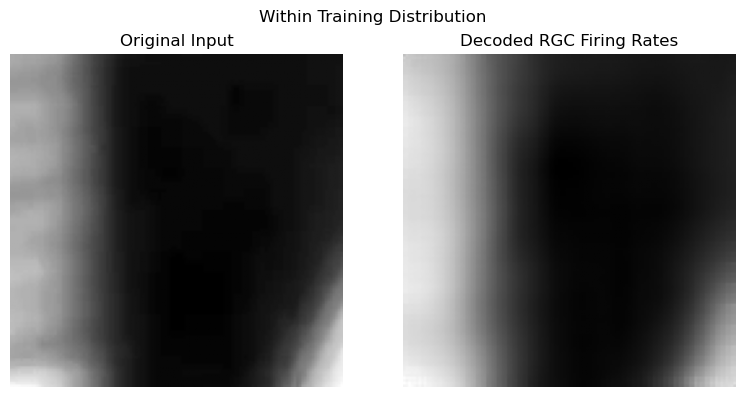

In [110]:
for x,y in train_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 63

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Training Distribution")
fig.set_tight_layout(True)
plt.show()

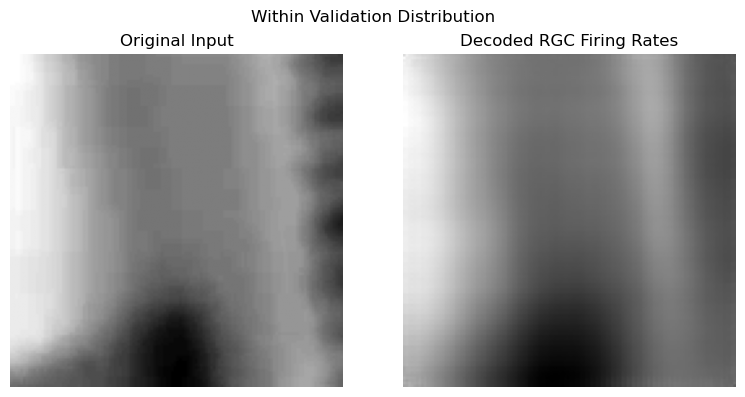

In [107]:
# what about something from the validation set?
for x,y in val_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 39

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Validation Distribution")
fig.set_tight_layout(True)
plt.show()

In [ ]:
# what about something entirely out of distribution
# let's try something a bit crazy:
# regenerating the entire video by creating patches from every portion of the video
!conda activate lnp_torch
!python sk_generate_activations.py

# Large training set size
uses multiple videos and few patches across each video

In [30]:
results = torch.load("/home/rotation/Desktop/LNP_LN_LN_Models/best_decoder_final.pt")
results.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

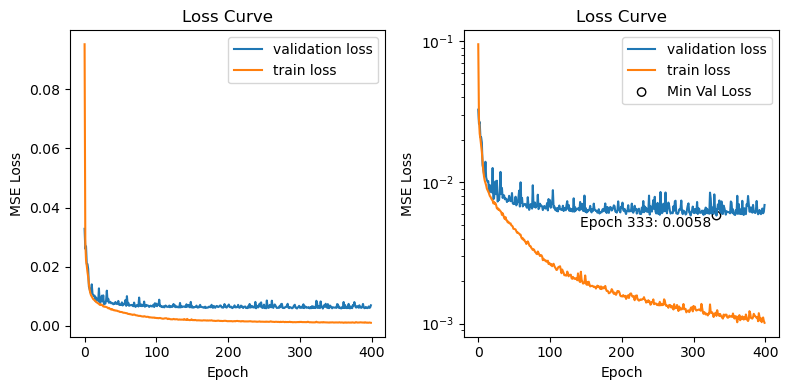

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(results["val_loss_history"], label="validation loss")
ax[0].plot(results["train_loss_history"], label="train loss")
ax[0].legend()

ax[0].set_title("Loss Curve")
ax[0].set_ylabel("MSE Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(results["val_loss_history"], label="validation loss")
ax[1].plot(results["train_loss_history"], label="train loss")

# show the minimum validation loss model
ax[1].scatter(332, min(results["val_loss_history"]), edgecolor="black", marker="o", facecolor="none", label="Min Val Loss")
ax[1].text(332-190, min(results["val_loss_history"])-0.001, f"Epoch 333: {min(results['val_loss_history']):.4f}")
ax[1].legend()

ax[1].set_yscale("log")
ax[1].set_title("Loss Curve")
ax[1].set_ylabel("MSE Loss")
ax[1].set_xlabel("Epoch")

fig.set_tight_layout(True)
plt.show()

In [32]:
# Let's see if we can rebuild some of the input images (and if we can try to rebuild some out of distribution images)
# 1. Load Configurations
train_cfg = u.read_params("params_training.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Data Preparation
dataset = RGCDataset("lnp_activations_bank/Video_1_acts.h5", "params_training.yaml")

# Validation split
val_split = train_cfg.get("validation_split", 0.1)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=False, num_workers=0)

# 3. Model Initialization
n_mosaics, max_n_cells = dataset.n_mosaics, dataset.max_n_cells
decoder_params = {
    "n_cells": n_mosaics * max_n_cells * dataset.input_window,
    "frame_shape": dataset.frame_shape,
    "num_blocks": train_cfg.get("num_blocks", 4),
    "num_kernels": train_cfg.get("num_kernels", 64),
    "bias": train_cfg.get("bias", False)
}

model = RetinaDecoder(decoder_params).to(device)
model.load_state_dict(torch.load("best_decoder.pt")["model_state_dict"])
model.eval()

Dataset compiled: 9405 valid spatiotemporal samples from 1 files.


RetinaDecoder(
  (w): Linear(in_features=6404, out_features=65536, bias=True)
  (mid_block): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BF_batchNorm()
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (upsample): ModuleDict(
    (3): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2), bias=False)
  )
  (decoder): ModuleDict(
    (3): Sequential(
      (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BF_batchNorm()
      (2): ReLU(inplace=True)
      (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BF_b

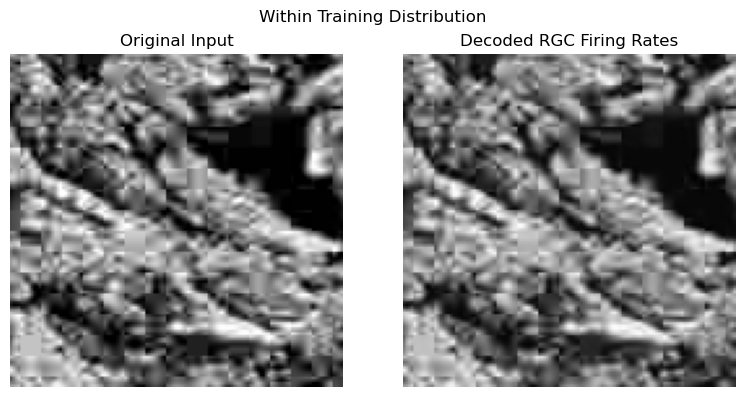

In [ ]:
for x_train,y_train in train_loader:
    break
x_train.shape, y_train.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 63

ax[0].imshow(y_train[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_val_cuda = x_train.to(device)
Y_train_pred = model(x_train_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Training Distribution")
fig.set_tight_layout(True)
plt.show()

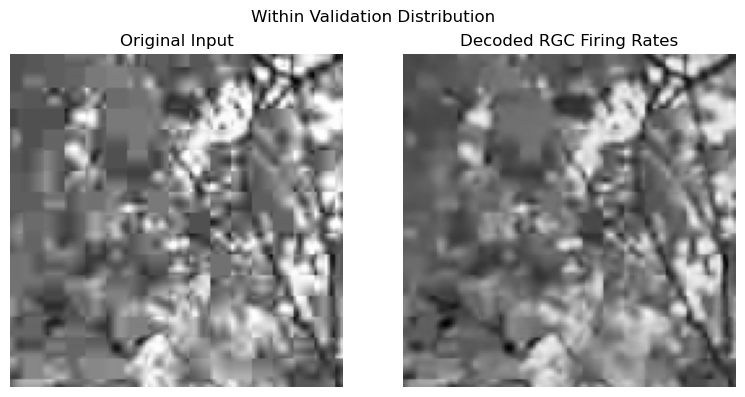

In [63]:
# what about something from the validation set?
for x_val,y_val in val_loader:
    break
x_val.shape, y_val.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 39

ax[0].imshow(y_val[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_val_cuda = x_val.to(device)
Y_val_pred = model(x_val_cuda)
ax[1].imshow(Y_val_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Validation Distribution")
fig.set_tight_layout(True)
plt.show()

YOO! turns out training on multiple datasets with multiple patches from each dataset actually works! who would have thought :))
Anyways, on recreating a video, check sk_reconstruct_video.py

## Blocking single cell types
Let's try reproducing these same images, but this time, when reproducing the images, we'll 0-out one cell type to see what the reproduced image looks like. This should give us some information about what that specific cell type is doing and what information it's capturing<br><br>

Cell types are organized in order ON parason, OFF parasol, ON midget, OFF midget

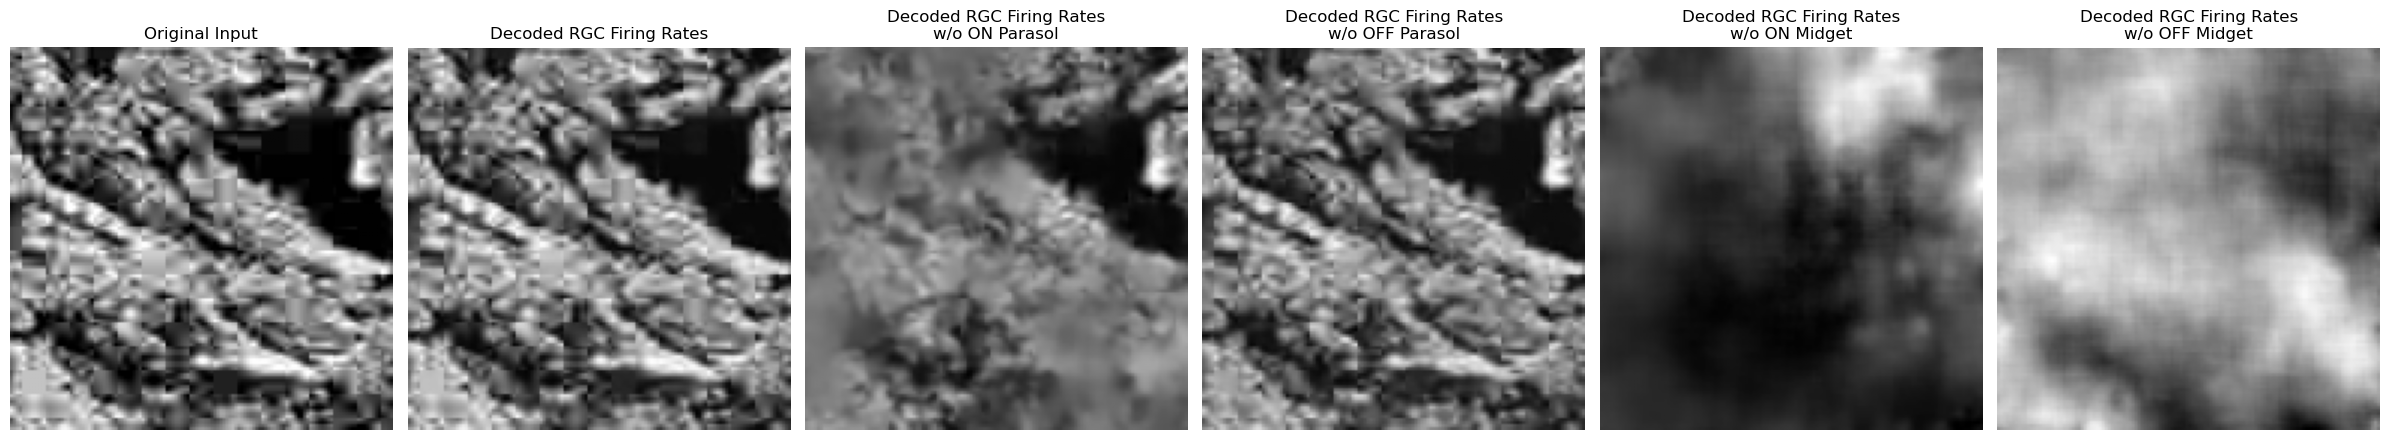

In [62]:
fig, ax = plt.subplots(1, 6, figsize=(24, 6))
ex = 63

ax[0].imshow(y_train[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# split our data into 4 samples with each missing a cell type
x_train_onparasol = x_train.clone(); x_train_onparasol[:,0,:,:] = 0.
x_train_offparasol = x_train.clone(); x_train_offparasol[:,1,:,:] = 0.
x_train_onmidget = x_train.clone(); x_train_onmidget[:,2,:,:] = 0.
x_train_offmidget = x_train.clone(); x_train_offmidget[:,3,:,:] = 0.

# do the forward pass (all cell types)
x_train_cuda = x_train.to(device)
Y_train_pred = model(x_train_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

# do the forward pass (no on parasol cells)
x_train_cuda = x_train_onparasol.to(device)
Y_train_pred = model(x_train_cuda)
ax[2].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[2].set_title("Decoded RGC Firing Rates\nw/o ON Parasol")

# do the forward pass (no off parasol cells)
x_train_cuda = x_train_offparasol.to(device)
Y_train_pred = model(x_train_cuda)
ax[3].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[3].set_title("Decoded RGC Firing Rates\nw/o OFF Parasol")

# do the forward pass (no on midget cells)
x_train_cuda = x_train_onmidget.to(device)
Y_train_pred = model(x_train_cuda)
ax[4].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[4].set_title("Decoded RGC Firing Rates\nw/o ON Midget")

# do the forward pass (no off midget cells)
x_train_cuda = x_train_offmidget.to(device)
Y_train_pred = model(x_train_cuda)
ax[5].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[5].set_title("Decoded RGC Firing Rates\nw/o OFF Midget")

for a in ax:
    a.axis("off")
    
fig.set_tight_layout(True)
plt.show()

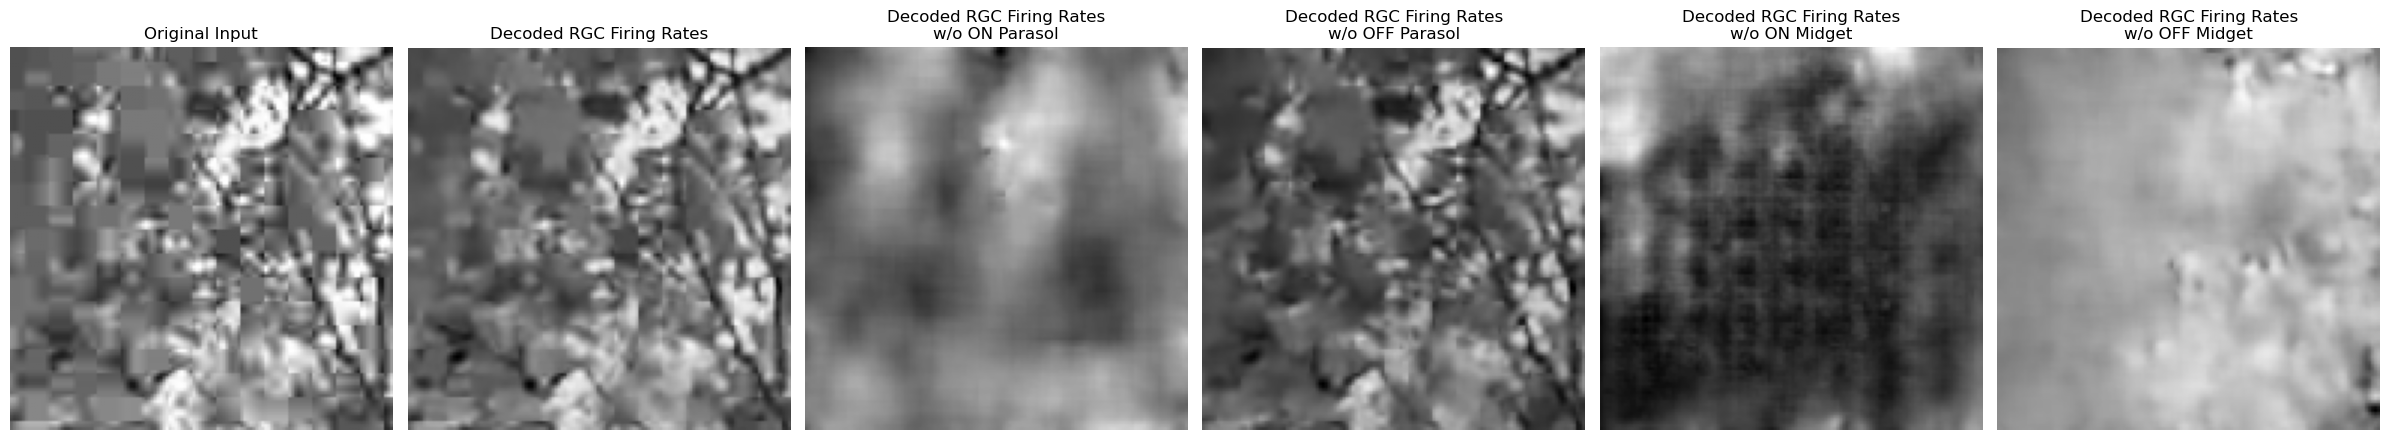

In [65]:
fig, ax = plt.subplots(1, 6, figsize=(24, 6))
ex = 39

ax[0].imshow(y_val[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# split our data into 4 samples with each missing a cell type
x_val_onparasol = x_val.clone(); x_val_onparasol[:,0,:,:] = 0.
x_val_offparasol = x_val.clone(); x_val_offparasol[:,1,:,:] = 0.
x_val_onmidget = x_val.clone(); x_val_onmidget[:,2,:,:] = 0.
x_val_offmidget = x_val.clone(); x_val_offmidget[:,3,:,:] = 0.

# do the forward pass (all cell types)
x_val_cuda = x_val.to(device)
Y_train_pred = model(x_val_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

# do the forward pass (no on parasol cells)
x_val_cuda = x_val_onparasol.to(device)
Y_train_pred = model(x_val_cuda)
ax[2].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[2].set_title("Decoded RGC Firing Rates\nw/o ON Parasol")

# do the forward pass (no off parasol cells)
x_val_cuda = x_val_offparasol.to(device)
Y_train_pred = model(x_val_cuda)
ax[3].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[3].set_title("Decoded RGC Firing Rates\nw/o OFF Parasol")

# do the forward pass (no on midget cells)
x_val_cuda = x_val_onmidget.to(device)
Y_train_pred = model(x_val_cuda)
ax[4].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[4].set_title("Decoded RGC Firing Rates\nw/o ON Midget")

# do the forward pass (no off midget cells)
x_val_cuda = x_val_offmidget.to(device)
Y_train_pred = model(x_val_cuda)
ax[5].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[5].set_title("Decoded RGC Firing Rates\nw/o OFF Midget")

for a in ax:
    a.axis("off")
    
fig.set_tight_layout(True)
plt.show()